# Linear Regression

This is my implementation using Linear Regression in housing price prediction. I used training data from [Kaggle-Housing Price Dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset).

For detail, I propose a linear function to predict housing price with 3 features: area, number of bedrooms, and number of bathrooms. 

To have a deep understand about this machine learning model, I implement **Gradient Descent** algorithm by Mini-batch method to get the optimal $\theta$. Then, I determine the exact $\theta$ by using **Normal Equation**, and check with given model from **Scikit-learn** library. 

In [7]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
filename = f"{path}/{os.listdir(path)[0]}"

df = pd.read_csv(filename)

m = df.shape[0]

X = df[['area', 'bedrooms', 'bathrooms']].values
y = df['price'].values

X_bias = np.concatenate((np.ones((m, 1)), X), axis = 1)

# 2. Split Train, Validation, and Test
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_bias, y,
    test_size = val_size,
    random_state = random_state,
    shuffle = is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size = test_size,
    random_state = random_state,
    shuffle = is_shuffle
)

# 3. Scale data
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

y_train = normalizer.fit_transform(y_train.reshape(-1, 1)).reshape(-1)
y_val = normalizer.transform(y_val.reshape(-1, 1)).reshape(-1)
y_test = normalizer.transform(y_test.reshape(-1, 1)).reshape(-1)

Epoch 1000 | Train Loss: 0.868552 | Val Loss: 0.855286
Epoch 2000 | Train Loss: 0.771806 | Val Loss: 0.744200
Epoch 3000 | Train Loss: 0.700820 | Val Loss: 0.667546
Epoch 4000 | Train Loss: 0.651633 | Val Loss: 0.615287
Epoch 5000 | Train Loss: 0.616222 | Val Loss: 0.580240
Epoch 6000 | Train Loss: 0.585339 | Val Loss: 0.557280
Epoch 7000 | Train Loss: 0.564188 | Val Loss: 0.542760
Epoch 8000 | Train Loss: 0.549830 | Val Loss: 0.534087
Epoch 9000 | Train Loss: 0.537532 | Val Loss: 0.529421
Epoch 10000 | Train Loss: 0.531622 | Val Loss: 0.527456
Mini-batch Gradient Descent:
 [[-2.46659414e-05]
 [ 3.65724373e-01]
 [ 1.59188382e-01]
 [ 2.76685427e-01]]

Difference of train_loss and val_loss: 0.0042
Average test_loss: 0.5001


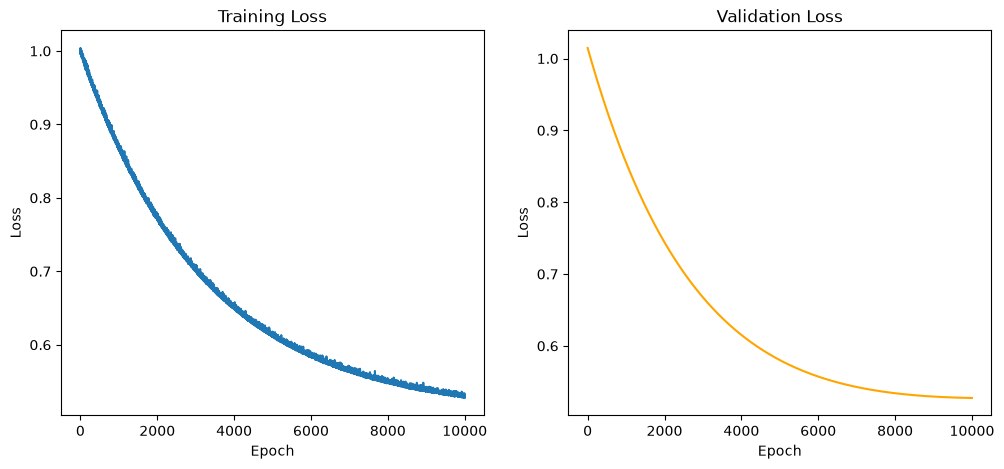

In [8]:
# ===== Mini-batch linear regression =====
# Important functions
def predict(theta, xi):
    return np.dot(xi, theta)

def compute_loss(yi, prediction):
    return (yi - prediction)**2

def minibatch_linear_regression(X_train, y_train, X_val, y_val, batch_size = 64, 
                                   epochs = 10000, learning_rate = 1e-5):
    (m, n) = X_train.shape
    theta = np.zeros(n)
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_loss = 0

        indecies = np.random.permutation(m)
        X_shuffled = X_train[indecies]
        y_shuffled = y_train[indecies]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i: i + batch_size]
            y_batch = y_shuffled[i: i + batch_size]

            y_pred = predict(theta, X_batch)
            error = y_pred - y_batch
            theta = theta - (learning_rate / len(y_batch)) * (X_batch.T @ error)
            train_loss += np.mean(compute_loss(y_batch, y_pred))

        num_batches = (m + batch_size - 1) // batch_size
        avg_train_loss = train_loss / num_batches
        train_losses.append(avg_train_loss)
        
        y_val_pred = predict(theta, X_val)
        val_loss = compute_loss(y_val, y_val_pred)
        avg_val_loss = np.mean(val_loss)
        val_losses.append(avg_val_loss)

        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1:4d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")
        
    return theta, train_losses, val_losses

# Print answer and plot diagram
theta_minibatch, train_losses, val_losses = minibatch_linear_regression(X_train, y_train, X_val, y_val, 32, 10000, 1e-5)

print(f"Mini-batch Gradient Descent:\n {theta_minibatch.reshape(-1, 1)}")

train_loss = train_losses[-1]
val_loss = val_losses[-1]
print(f"\nDifference of train_loss and val_loss: {abs(train_loss - val_loss):.4f}")

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].plot(train_losses)
ax[0].set(xlabel = 'Epoch', ylabel = 'Loss')
ax[0].set_title('Training Loss')

ax[1].plot(val_losses, 'orange')
ax[1].set(xlabel = 'Epoch', ylabel = 'Loss')
ax[1].set_title('Validation Loss')

test_loss = np.mean(compute_loss(y_test, predict(theta_minibatch, X_test)))
print(f"Average test_loss: {test_loss:.4f}")

In [ ]:
# ===== Normal equation =====
X_bias = np.concatenate((np.ones((m,1)), X), axis = 1) # Add a column filled by 1 at the left of data frame
theta_normal = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
theta_normal = theta_normal.reshape(-1, 1)

print(f"Normal Equation:\n{theta_normal}")

# ===== Scikit-learn model =====
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
theta_sklearn = np.concatenate((model.intercept_.reshape(-1,1),model.coef_.reshape(-1,1)), axis = 0)

print(f"Scikit-learn:\n{theta_sklearn}")

Normal Equation:
[[-1.73171608e+05]
 [ 3.78762754e+02]
 [ 4.06820034e+05]
 [ 1.38604950e+06]]
Scikit-learn:
[[-1.73171608e+05]
 [ 3.78762754e+02]
 [ 4.06820034e+05]
 [ 1.38604950e+06]]
